# Train on 2018, test on 2017

**Question.** The reverse direction: can a model trained only on CSE-CIC-IDS2018 still detect the
attacks in CIC-IDS2017? 2018 has more attack flows and more of some families (Bot, Infiltration),
but no PortScan or Heartbleed, so those two are unseen attack types in this direction.

`notebooks/cross_year_diagnostics.ipynb` found three causes of the failure: the flow tool
measured header-based features differently, the networks and attack tools differ, and the class
mix differs. This notebook tests two fixes aimed at the first two causes (code in
`src/models/cross_dataset.py`):

| Variant | What changes |
|---|---|
| `baseline` | all 71 features, one scaler fit on the training year |
| `drop_header` | drop the 3 header-length features the flow tool measured differently in the two years (`min_seg_size_forward`, `Fwd/Bwd Header Length`) |
| `drop_network` | drop destination port and the 2 initial TCP window sizes, which describe one particular network |
| `per_domain` | each year is quantile-normalized on its **own unlabeled traffic**, so values mean "how unusual for this network" |
| `header_and_domain` | `drop_header` + `per_domain` |

Each variant trains logistic regression and LightGBM on 2018 (benign downsampled to 200k in
training only) and is tested on a held-out 20% of 2018 and on all of 2017.

**Written before the first run.** We expected removing tool- and network-dependent features, and
normalizing each year on its own traffic, to help most on attack types that look alike in both
years (slowloris, Bot) and little on types whose behaviour changed (DoS Hulk, SSH brute force).
The first run dropped the header and network features together in one variant, and LightGBM got
much worse. This version drops them separately to see which group matters. No variant is chosen
using 2017 labels: all five are reported.

**Metrics.** PR-AUC (2018 benign rows weighted by 10 to undo the 10% sample) and recall at a 1%
false positive rate. The 1% threshold is set on each test set's own benign flows, which is
optimistic but gives every model the same alert budget.

In [1]:
import sys
sys.path.insert(0, "..")  # make src/ importable from notebooks/

import json
import warnings
import matplotlib.pyplot as plt
import pandas as pd

from src.models.cross_dataset import run_direction

warnings.filterwarnings("ignore", message="X does not have valid feature names")
pd.set_option("display.width", 200)

SOURCE, TARGET = "2018", "2017"
summary, per_family = run_direction(SOURCE, TARGET)

Exception ignored in: <function ResourceTracker.__del__ at 0x10c22e660>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/opt/anaconda3/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/opt/anaconda3/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x103d26660>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/opt/anaconda3/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/opt/anaconda3/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x111d2e660>
Traceback (most recent call last

Exception ignored in: <function ResourceTracker.__del__ at 0x112326660>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/opt/anaconda3/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/opt/anaconda3/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes


Exception ignored in: <function ResourceTracker.__del__ at 0x105f2e660>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/opt/anaconda3/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/opt/anaconda3/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes


## Results

In [2]:
summary.round(3)

n features  PR-AUC  no-skill  recall at 1% FPR
variant           model               test set                                                         
baseline          Logistic regression 2018 held-out              71   0.761     0.103             0.369
                                      2017 (other year)          71   0.144     0.169             0.029
                  LightGBM            2018 held-out              71   0.969     0.103             0.931
                                      2017 (other year)          71   0.174     0.169             0.011
drop_header       Logistic regression 2018 held-out              68   0.736     0.103             0.347
                                      2017 (other year)          68   0.200     0.169             0.049
                  LightGBM            2018 held-out              68   0.969     0.103             0.930
                                      2017 (other year)          68   0.562     0.169             0.073
drop_network      Logistic regression 2018 held-out              68   0.724     0.103             0.507
                                      2017 (other year)          68   0.110     0.169             0.002
                  LightGBM            2018 held-out              68   0.962     0.103             0.915
                                      2017 (other year)          68   0.233     0.169             0.013
per_domain        Logistic regression 2018 held-out              71   0.879     0.103             0.859
                                      2017 (other year)          71   0.164     0.169             0.019
                  LightGBM            2018 held-out              71   0.970     0.103             0.930
                                      2017 (other year)          71   0.119     0.169             0.000
header_and_domain Logistic regression 2018 held-out              68   0.853     0.103             0.805
                                      2017 (other year)          68   0.343     0.169             0.091
                  LightGBM            2018 held-out              68   0.969     0.103             0.930
                                      2017 (other year)          68   0.264     0.169             0.112

In [3]:
# Same year vs. other year, side by side
pivot = summary["PR-AUC"].unstack("test set").round(3)
pivot["drop"] = (pivot.iloc[:, 0] - pivot.iloc[:, 1]).round(3)
pivot

test set                               2017 (other year)  2018 held-out   drop
variant           model                                                       
baseline          LightGBM                         0.174          0.969 -0.795
                  Logistic regression              0.144          0.761 -0.617
drop_header       LightGBM                         0.562          0.969 -0.407
                  Logistic regression              0.200          0.736 -0.536
drop_network      LightGBM                         0.233          0.962 -0.729
                  Logistic regression              0.110          0.724 -0.614
header_and_domain LightGBM                         0.264          0.969 -0.705
                  Logistic regression              0.343          0.853 -0.510
per_domain        LightGBM                         0.119          0.970 -0.851
                  Logistic regression              0.164          0.879 -0.715

### Which attack families does each variant catch in 2017?

Recall per attack family at the 1% false positive threshold, on the other year's data.

In [4]:
other = [c for c in per_family.columns if "other year" in c[2]]
per_family[other].droplevel(2, axis=1).round(3)

baseline                  drop_header                 drop_network                   per_domain            header_and_domain         
                      Logistic regression LightGBM Logistic regression LightGBM Logistic regression LightGBM Logistic regression LightGBM Logistic regression LightGBM
Bot                                 0.003    0.000               0.021    0.026               0.000    0.000               0.000      0.0               0.000    0.079
Brute force (FTP/SSH)               0.032    0.002               0.000    0.962               0.047    0.245               0.324      0.0               0.554    0.199
DDoS                                0.055    0.000               0.124    0.122               0.000    0.000               0.000      0.0               0.230    0.000
DoS                                 0.025    0.024               0.024    0.031               0.001    0.017               0.015      0.0               0.016    0.000
Infiltration                        0.194    0.000               0.333    0.000               0.194    0.000               0.000      0.0               0.222    0.028
Web attack                          0.040    0.000               0.000    0.035               0.041    0.028               0.000      0.0               0.000    0.000
Heartbleed                          1.000    0.000               0.000    0.000               1.000    0.000               0.000      0.0               0.000    0.000
PortScan                            0.000    0.000               0.000    0.004               0.000    0.000               0.024      0.0               0.011    0.507

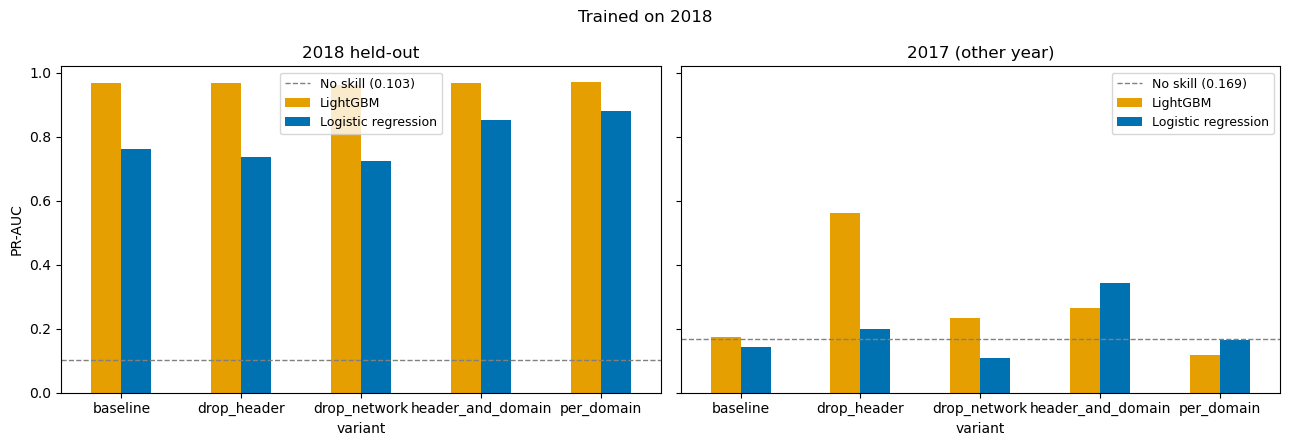

In [5]:
# Okabe-Ito colorblind-safe palette
colors = {"Logistic regression": "#0072B2", "LightGBM": "#E69F00"}
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, test_set in zip(axes, summary.index.get_level_values("test set").unique()):
    data = summary.xs(test_set, level="test set")["PR-AUC"].unstack("model")
    data.plot.bar(ax=ax, color=[colors[m] for m in data.columns], rot=0)
    no_skill = summary.xs(test_set, level="test set")["no-skill"].iloc[0]
    ax.axhline(no_skill, color="gray", linestyle="--", linewidth=1, label=f"No skill ({no_skill:.3f})")
    ax.set_title(test_set)
    ax.set_xlabel("variant")
    ax.set_ylim(0, 1.02)
    ax.legend(fontsize=9)
axes[0].set_ylabel("PR-AUC")
fig.suptitle(f"Trained on {SOURCE}")
fig.tight_layout()
plt.show()

In [6]:
# Save for the README and reports
out = {
    "summary": summary.reset_index().to_dict(orient="records"),
    "per_family_other_year": {f"{v} | {m}": col for (v, m, t), col in per_family.to_dict().items() if "other year" in t},
}
with open(f"../reports/cross_year_train_{SOURCE}_test_{TARGET}.json", "w") as fh:
    json.dump(out, fh, indent=2)

## Summary

All numbers are from the tables above. One seed and one split; the 1% threshold is set on 2017's
own benign flows, which is optimistic.

**2018 is harder even in-year.** On held-out 2018, LightGBM scores PR-AUC 0.969 but logistic
regression only 0.761 (against 0.954 for logistic regression on 2017).

**Unchanged, nothing transfers.** Baseline LightGBM scores PR-AUC 0.174 on 2017 against a no-skill
of 0.169, with recall 0.011 at a 1% false positive rate. Logistic regression scores 0.144, below
chance.

**The fixes work the opposite way from the other direction.**
- Dropping the header-length features lifts LightGBM to PR-AUC 0.562 and brute-force recall
  from 0.002 to 0.962. Trained on 2017, the same change made LightGBM worse.
- Header-length drop plus per-domain normalization gives the best recall at 1% for both models:
  0.091 for logistic regression and 0.112 for LightGBM. That LightGBM catches 0.507 of 2017's
  PortScan, an attack type that never appears in 2018. This is one run, so treat it as a lead
  rather than a result.

**Not fixed by anything:** DoS is at most 0.031 in every variant, even though 2018 has 196,556 DoS
flows. The diagnostics show 2018's DoS Hulk flows look very different from 2017's.

**Across both notebooks.** No single fix helps in both directions. Dropping the header features
hurts when training on 2017 (LightGBM PR-AUC 0.557 to 0.504) and helps when training on 2018
(0.174 to 0.562). Without labeled data from the new network, there is no way to know in advance
which fix to use.